# SplitFed Demonstration Notebook

This notebook provides a simple interactive setup of the Split Federated Learning (SplitFed) simulator.
We will load the MNIST dataset, partition it among 3 simulated clients, and run a short training loop.

### Step 0: Remote Server Setup

If you are running this notebook on a remote Jupyter server (like Google Colab), run the following cell to clone the repository, install dependencies, and set the correct working directory.

In [1]:
import os, subprocess, sys
from pathlib import Path

repo_url = "https://github.com/tomal66/ad-sfl.git"
repo_path = Path("/content/ad-sfl")  # Colab workspace

def run(cmd, cwd=None):
    return subprocess.run(cmd, cwd=cwd, check=True, text=True, capture_output=True)

# 1) Clone if missing
if not repo_path.exists():
    subprocess.run(["git", "clone", repo_url, str(repo_path)], check=True)

# 2) Sanity check: must be a git repo now
if not (repo_path / ".git").exists():
    raise RuntimeError(
        f"{repo_path} exists but is not a git repo (no .git). "
        f"Delete/rename that folder or choose a different repo_path."
    )

# 3) Update: fetch + reset to remote default branch
subprocess.run(["git", "fetch", "--all", "--prune"], cwd=repo_path, check=True)

default_ref = run(["git", "symbolic-ref", "refs/remotes/origin/HEAD"], cwd=repo_path).stdout.strip()
branch = "attack"  # e.g., main / master

subprocess.run(["git", "checkout", branch], cwd=repo_path, check=True)
subprocess.run(["git", "reset", "--hard", f"origin/{branch}"], cwd=repo_path, check=True)
subprocess.run(["git", "clean", "-fd"], cwd=repo_path, check=True)

# 4) Set cwd to repo folder
os.chdir(repo_path)
print("CWD:", os.getcwd())
print("Branch:", branch)
print("HEAD:", run(["git", "rev-parse", "HEAD"], cwd=repo_path).stdout.strip())

# 5) Install datasets (for huggingface) and other requirements
subprocess.run([sys.executable, "-m", "pip", "install", "datasets"], check=True)
req = repo_path / "requirements.txt"
if req.exists():
    subprocess.run([sys.executable, "-m", "pip", "install", "-r", str(req)], check=True)

CWD: C:\content\ad-sfl
Branch: attack
HEAD: f6b5c1867e9808e0658698c6d26b8dbb1eadbe85


In [2]:
import torch
from src.data.datasets import get_datasets
from src.data.partition import partition_data_iid, partition_data_dirichlet
from src.models.split import ClientModel, ServerModel
from src.core.client import SplitFedClient
from src.core.server import SplitFedServer
from src.core.seed import set_seed

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


### Step 1: Load and Partition Data

In [3]:
# --- HYPERPARAMETERS & REPRODUCIBILITY ---
num_clients = 10
batch_size = 64
learning_rate = 0.001

GLOBAL_SEED = 42
set_seed(GLOBAL_SEED)
DATASET = "MNIST"

# Non-IID Dirichlet alpha (smaller means more unbalanced)
DIRICHLET_ALPHA = 1

# --- ATTACK HYPERPARAMETERS ---
ATTACK_TYPE = 'pair_flip'    # Options: 'none', 'pair_flip', 'targeted', 'backdoor'
MALICIOUS_FRACTION = 0.5    # Fraction of malicious clients

# Define attack-specific parameters
ATTACK_KWARGS = {
    "backdoor_poison_fraction": 1.0,
    "backdoor_target_label": 0,
    "backdoor_source_labels": [1, 2, 3],
    "trigger_size": 3,
    "trigger_value_raw": 1.0,
    "trigger_pos": "br",
    "flip_fraction": 1.0,
    "label_pairs_to_flip": [(1, 8), (2, 7), (3, 9)]
}
# -----------------------------------------
# Hugging Face Token (if required for gated datasets like ImageNet)
HF_TOKEN = None

print(f"Loading {DATASET} dataset...")
train_data, test_data = get_datasets(dataset_name=DATASET, hf_token=HF_TOKEN)

print(f"Partitioning data into Non-IID subsets (Dirichlet alpha={DIRICHLET_ALPHA})...")
client_datasets = partition_data_dirichlet(train_data, num_clients, alpha=DIRICHLET_ALPHA)


Global seed set to: 42
Loading MNIST dataset...


Partitioning data into Non-IID subsets (Dirichlet alpha=1)...


### Step 2: Initialize Server and Client Models

In SplitFed, a portion of the network is on the client, and the rest is on the server.

In [4]:
import copy
import numpy as np

from src.models.split import get_split_models
from src.data.poisoned_dataset import PoisonedDataset

base_client_model, server_model = get_split_models(DATASET)
server = SplitFedServer(model=server_model, num_clients=num_clients, lr=learning_rate, device=device)

# Determine malicious clients
num_malicious = int(num_clients * MALICIOUS_FRACTION)
malicious_clients_indices = set(np.random.choice(num_clients, num_malicious, replace=False))

clients = []
for i in range(num_clients):
    client_model = copy.deepcopy(base_client_model)
    is_mal = i in malicious_clients_indices
    c_dataset = client_datasets[i]
    if is_mal and ATTACK_TYPE != 'none':
        c_dataset = PoisonedDataset(c_dataset, attack_type=ATTACK_TYPE,
                                    attack_kwargs=ATTACK_KWARGS, dataset_name=DATASET,
                                    seed=GLOBAL_SEED+i)
    client = SplitFedClient(client_id=i, model=client_model, dataset=c_dataset, 
                            batch_size=batch_size, lr=learning_rate, device=device,
                            is_malicious=is_mal)
    clients.append(client)

print(f"Initialized 1 Server and {num_clients} Clients.")
print(f"Injected '{ATTACK_TYPE}' into {len(malicious_clients_indices)} malicious clients: {malicious_clients_indices}")


Initialized 1 Server and 10 Clients.
Injected 'pair_flip' into 5 malicious clients: {np.int32(1), np.int32(4), np.int32(5), np.int32(7), np.int32(9)}


In [5]:
import torch
from collections import OrderedDict

def count_params(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    non_trainable = total - trainable
    return {"total": total, "trainable": trainable, "non_trainable": non_trainable}

def format_counts(title, d):
    return f"{title}: total={d['total']:,} | trainable={d['trainable']:,} | non-trainable={d['non_trainable']:,}"

# --- client / server ---
client_counts = count_params(base_client_model)
server_counts = count_params(server_model)

# --- combined (client + server) ---
# safest: sum counts (no risk of name collisions)
combined_counts = {
    "total": client_counts["total"] + server_counts["total"],
    "trainable": client_counts["trainable"] + server_counts["trainable"],
    "non_trainable": client_counts["non_trainable"] + server_counts["non_trainable"],
}

print(format_counts("CLIENT", client_counts))
print(format_counts("SERVER", server_counts))
print(format_counts("COMBINED", combined_counts))

CLIENT: total=320 | trainable=320 | non-trainable=0
SERVER: total=421,322 | trainable=421,322 | non-trainable=0
COMBINED: total=421,642 | trainable=421,642 | non-trainable=0


### Step 3: Simulation Loop

Training:   0%|          | 0/50 [00:00<?, ?round/s]

C:\Users\Tomal\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Training simulation complete. Plotting accuracy...


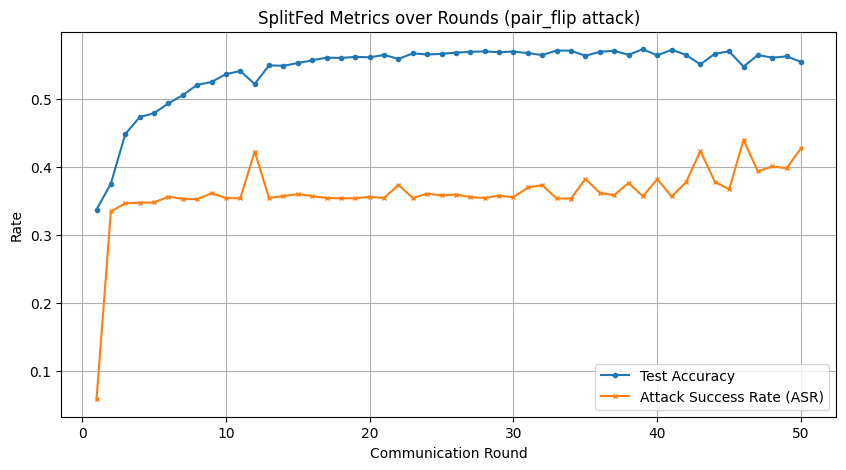

In [6]:
import matplotlib.pyplot as plt
from tqdm.auto import trange
from torch.utils.data import DataLoader
from src.algorithms import run_sfl_round
from src.algorithms.evaluate import (
    evaluate_accuracy, 
    evaluate_backdoor_asr, 
    evaluate_targeted_asr, 
    evaluate_pair_flip_asr
)

rounds = 50
historical_train_acc = []
historical_test_acc = []
historical_asr = []

test_loader = DataLoader(
    test_data, 
    batch_size=batch_size, 
    shuffle=False, 
    num_workers=4, 
    pin_memory=True
)

pbar = trange(rounds, desc="Training", unit="round")
for r in pbar:
    train_loss, train_acc = run_sfl_round(clients, server, local_epochs=1)
    
    # Evaluate Test Acc and ASR
    eval_client = clients[0].model
    test_acc = evaluate_accuracy(eval_client, server.model, test_loader, device)
    
    asr = 0.0
    if ATTACK_TYPE == 'backdoor':
        asr = evaluate_backdoor_asr(eval_client, server.model, test_loader, 
                                    ATTACK_KWARGS.get('backdoor_source_labels', []), 
                                    ATTACK_KWARGS.get('backdoor_target_label', 0), 
                                    ATTACK_KWARGS, device)
    elif ATTACK_TYPE == 'targeted':
        asr = evaluate_targeted_asr(eval_client, server.model, test_loader, 
                                    ATTACK_KWARGS.get('targeted_source_labels', []), 
                                    ATTACK_KWARGS.get('targeted_target_label', 0), 
                                    device)
    elif ATTACK_TYPE == 'pair_flip':
        asr = evaluate_pair_flip_asr(eval_client, server.model, test_loader, 
                                     ATTACK_KWARGS.get('label_pairs_to_flip', []), 
                                     device)
    
    historical_train_acc.append(train_acc)
    historical_test_acc.append(test_acc)
    historical_asr.append(asr)
    
    pbar.set_postfix(loss=f"{train_loss:.4f}", test_acc=f"{test_acc:.4f}", asr=f"{asr:.4f}")

print("Training simulation complete. Plotting accuracy...")
plt.figure(figsize=(10, 5))
plt.plot(range(1, rounds + 1), historical_test_acc, marker="o", markersize=3, label="Test Accuracy")
plt.plot(range(1, rounds + 1), historical_asr, marker="x", markersize=3, label="Attack Success Rate (ASR)")
plt.title(f"SplitFed Metrics over Rounds ({ATTACK_TYPE} attack)")
plt.xlabel("Communication Round")
plt.ylabel("Rate")
plt.legend()
plt.grid(True)
plt.show()
